Dataset Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Missing Values:
step              0
type              0
amount            0

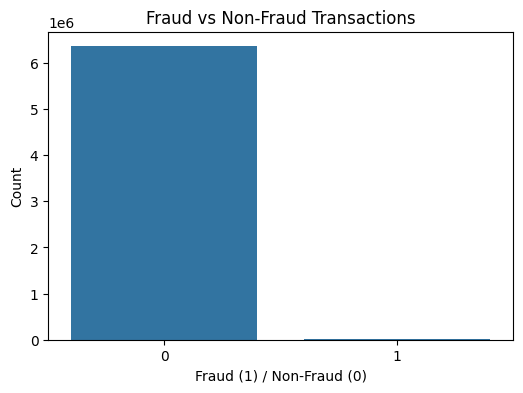

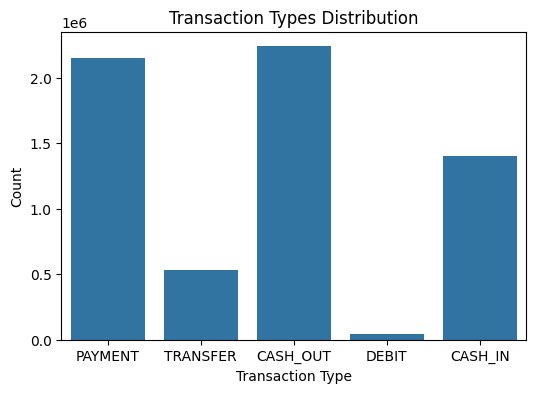

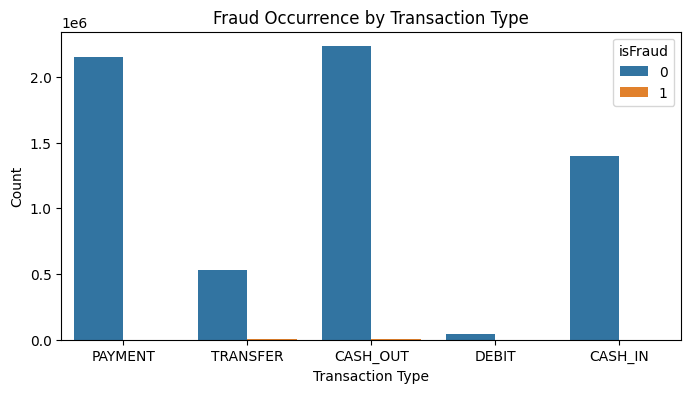

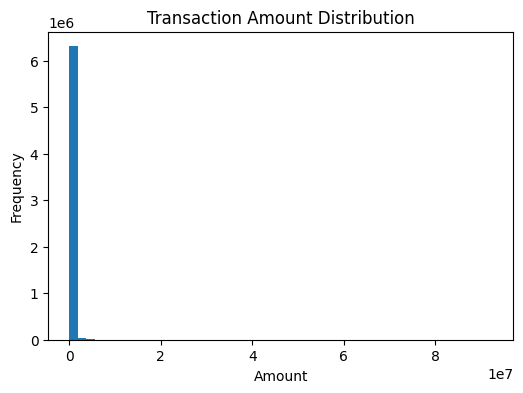

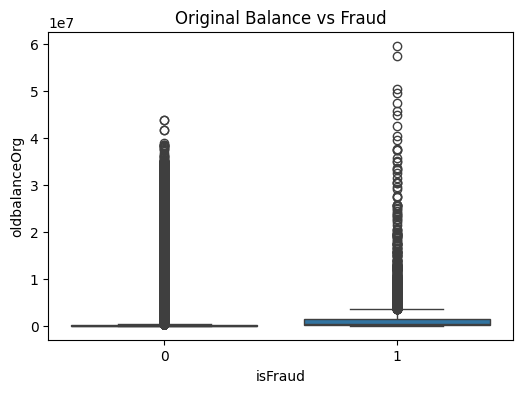

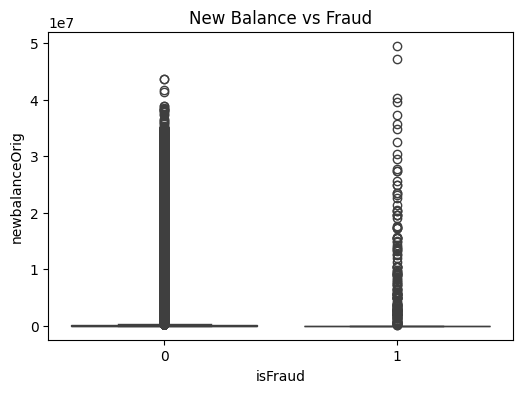

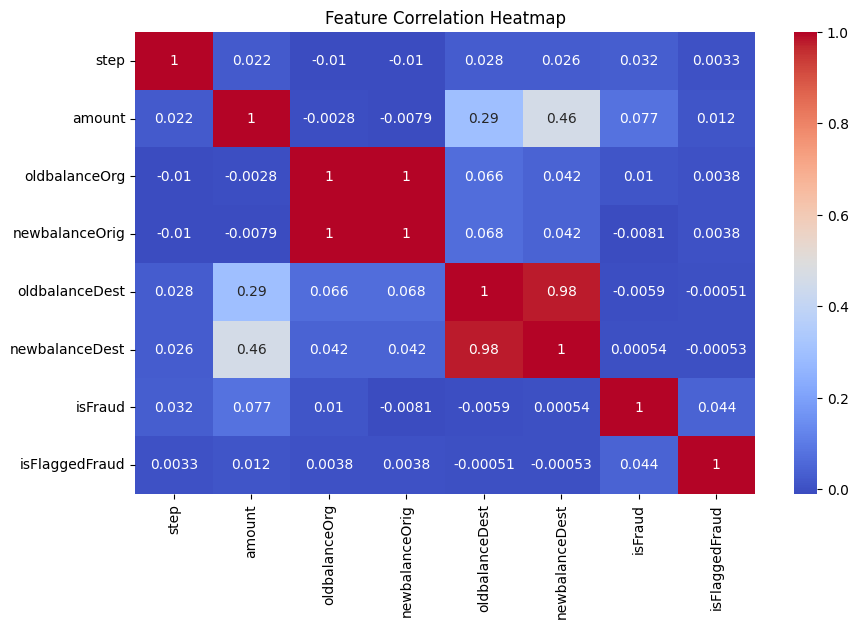


Fraud Ratio:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
Balanced Data Shape: (16426, 11)
Training Samples: (13140, 7)
Testing Samples: (3286, 7)

Logistic Regression
Accuracy: 0.9184418746195983

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1643
           1       0.94      0.89      0.92      1643

    accuracy                           0.92      3286
   macro avg       0.92      0.92      0.92      3286
weighted avg       0.92      0.92      0.92      3286


Confusion Matrix:
[[1557   86]
 [ 182 1461]]

Random Forest
Accuracy: 0.9930006086427268

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1643
           1       0.99      1.00      0.99      1643

    accuracy                           0.99      3286
   macro avg       0.99      0.99      0.99      3286
weighted avg       0.99      0.99      0.

In [ ]:
# =========================
# Financial Fraud Detection
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv("/content/Fraud.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 2. EDA
# ==========================================

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
#  Dataset Overview
# ------------------------------------------

print("Dataset Shape:", df.shape)
print("\nDataset Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# ------------------------------------------
# Missing Values
# ------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
# Class Distribution (Fraud vs Non-Fraud)
# ------------------------------------------

print("\nFraud Distribution:")
print(df['isFraud'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud (1) / Non-Fraud (0)")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Transaction Type Distribution
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Transaction Types Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Fraud by Transaction Type
# ------------------------------------------

plt.figure(figsize=(8,4))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud Occurrence by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Transaction Amount Distribution
# ------------------------------------------

plt.figure(figsize=(6,4))
plt.hist(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# Balance Comparison
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='oldbalanceOrg', data=df)
plt.title("Original Balance vs Fraud")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='newbalanceOrig', data=df)
plt.title("New Balance vs Fraud")
plt.show()

# ------------------------------------------
# Correlation Analysis
# ------------------------------------------

numeric_df = df.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# ==========================================
# 3. Handle Imbalanced Data
# ==========================================

print("\nFraud Ratio:")
print(df['isFraud'].value_counts(normalize=True))

# Undersampling for simplicity
fraud = df[df['isFraud']==1]
normal = df[df['isFraud']==0].sample(len(fraud), random_state=42)

df_balanced = pd.concat([fraud, normal])

print("Balanced Data Shape:", df_balanced.shape)

# ==========================================
# 4. Feature Selection
# ==========================================

# Drop unnecessary columns
df_balanced = df_balanced.drop(['nameOrig','nameDest','isFlaggedFraud'], axis=1)

# Encode transaction type
encoder = LabelEncoder()
df_balanced['type'] = encoder.fit_transform(df_balanced['type'])

# Features and target
X = df_balanced.drop('isFraud', axis=1)
y = df_balanced['isFraud']

# ==========================================
# 5. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

# ==========================================
# 6. Machine Learning Models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

for name, model in models.items():

    print("\n==============================")
    print(name)
    print("==============================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))